# Stage 14 — Figures, poster, and reporting

_Pipeline stage 14 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Publication figures

Render scripts + presentation notebooks produce the result figures: ROC panels, the
Mars coupling map, **vector** contact sheets (high-confidence and disagreement cases),
and per-outlet drawings. Build: `python -m channel_heads make-result-figures` /
`generate-poster-figures` and `scripts/rendering/*`.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
figdir = MARS_OUT / 'figures_combined'
pngs = sorted(figdir.glob('*.png'))
print(f'{len(pngs)} figures in {figdir.relative_to(ROOT)}:')
for f in pngs: print('  ', f.name)

7 figures in data/Mars/model_outputs/figures_combined:
   contact_sheet_disagreement.png
   contact_sheet_high_conf_both.png
   mars_networks_channels.png
   probability_histograms.png
   scatter_emb_vs_logit.png
   scatter_tabular_vs_emb.png
   touching_pct_by_variant.png


mars_networks_channels.png


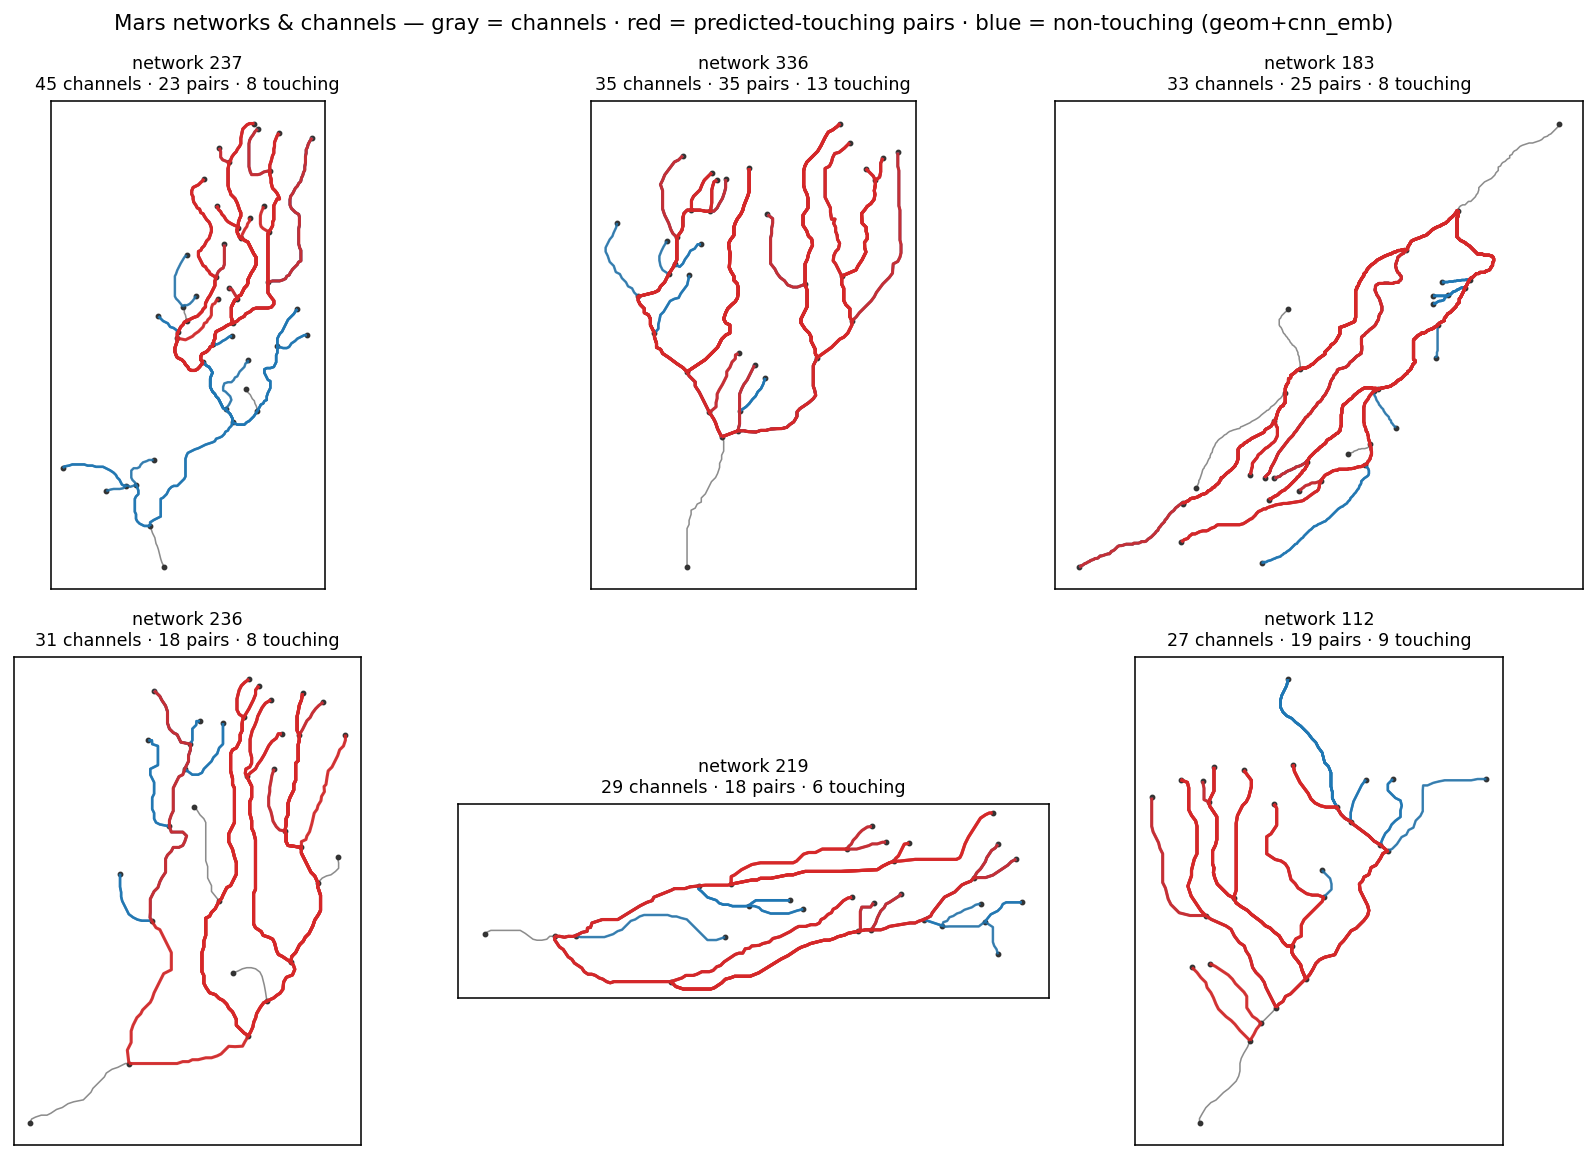

contact_sheet_high_conf_both.png


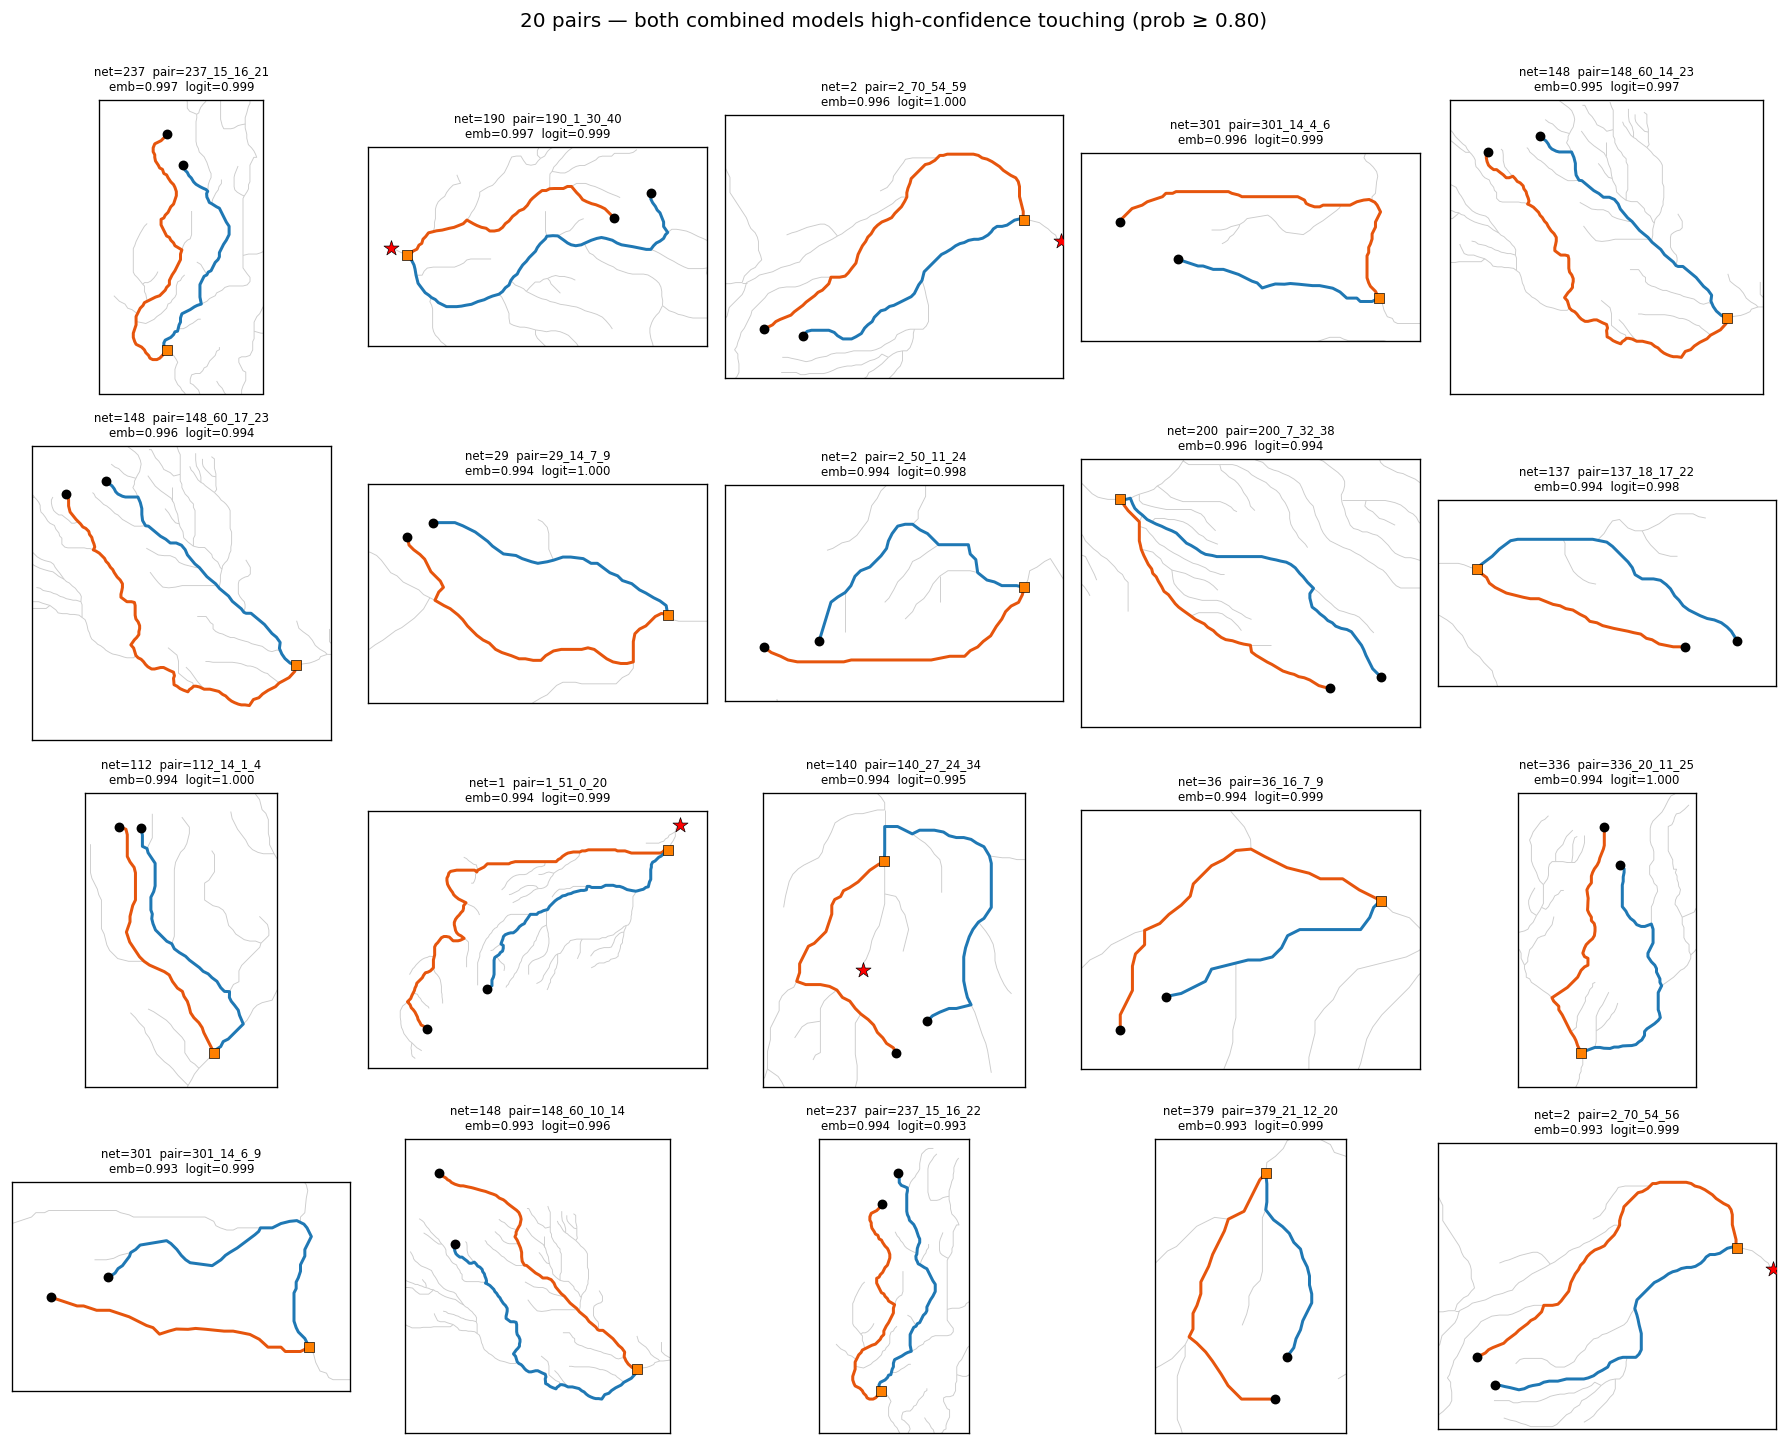

contact_sheet_disagreement.png


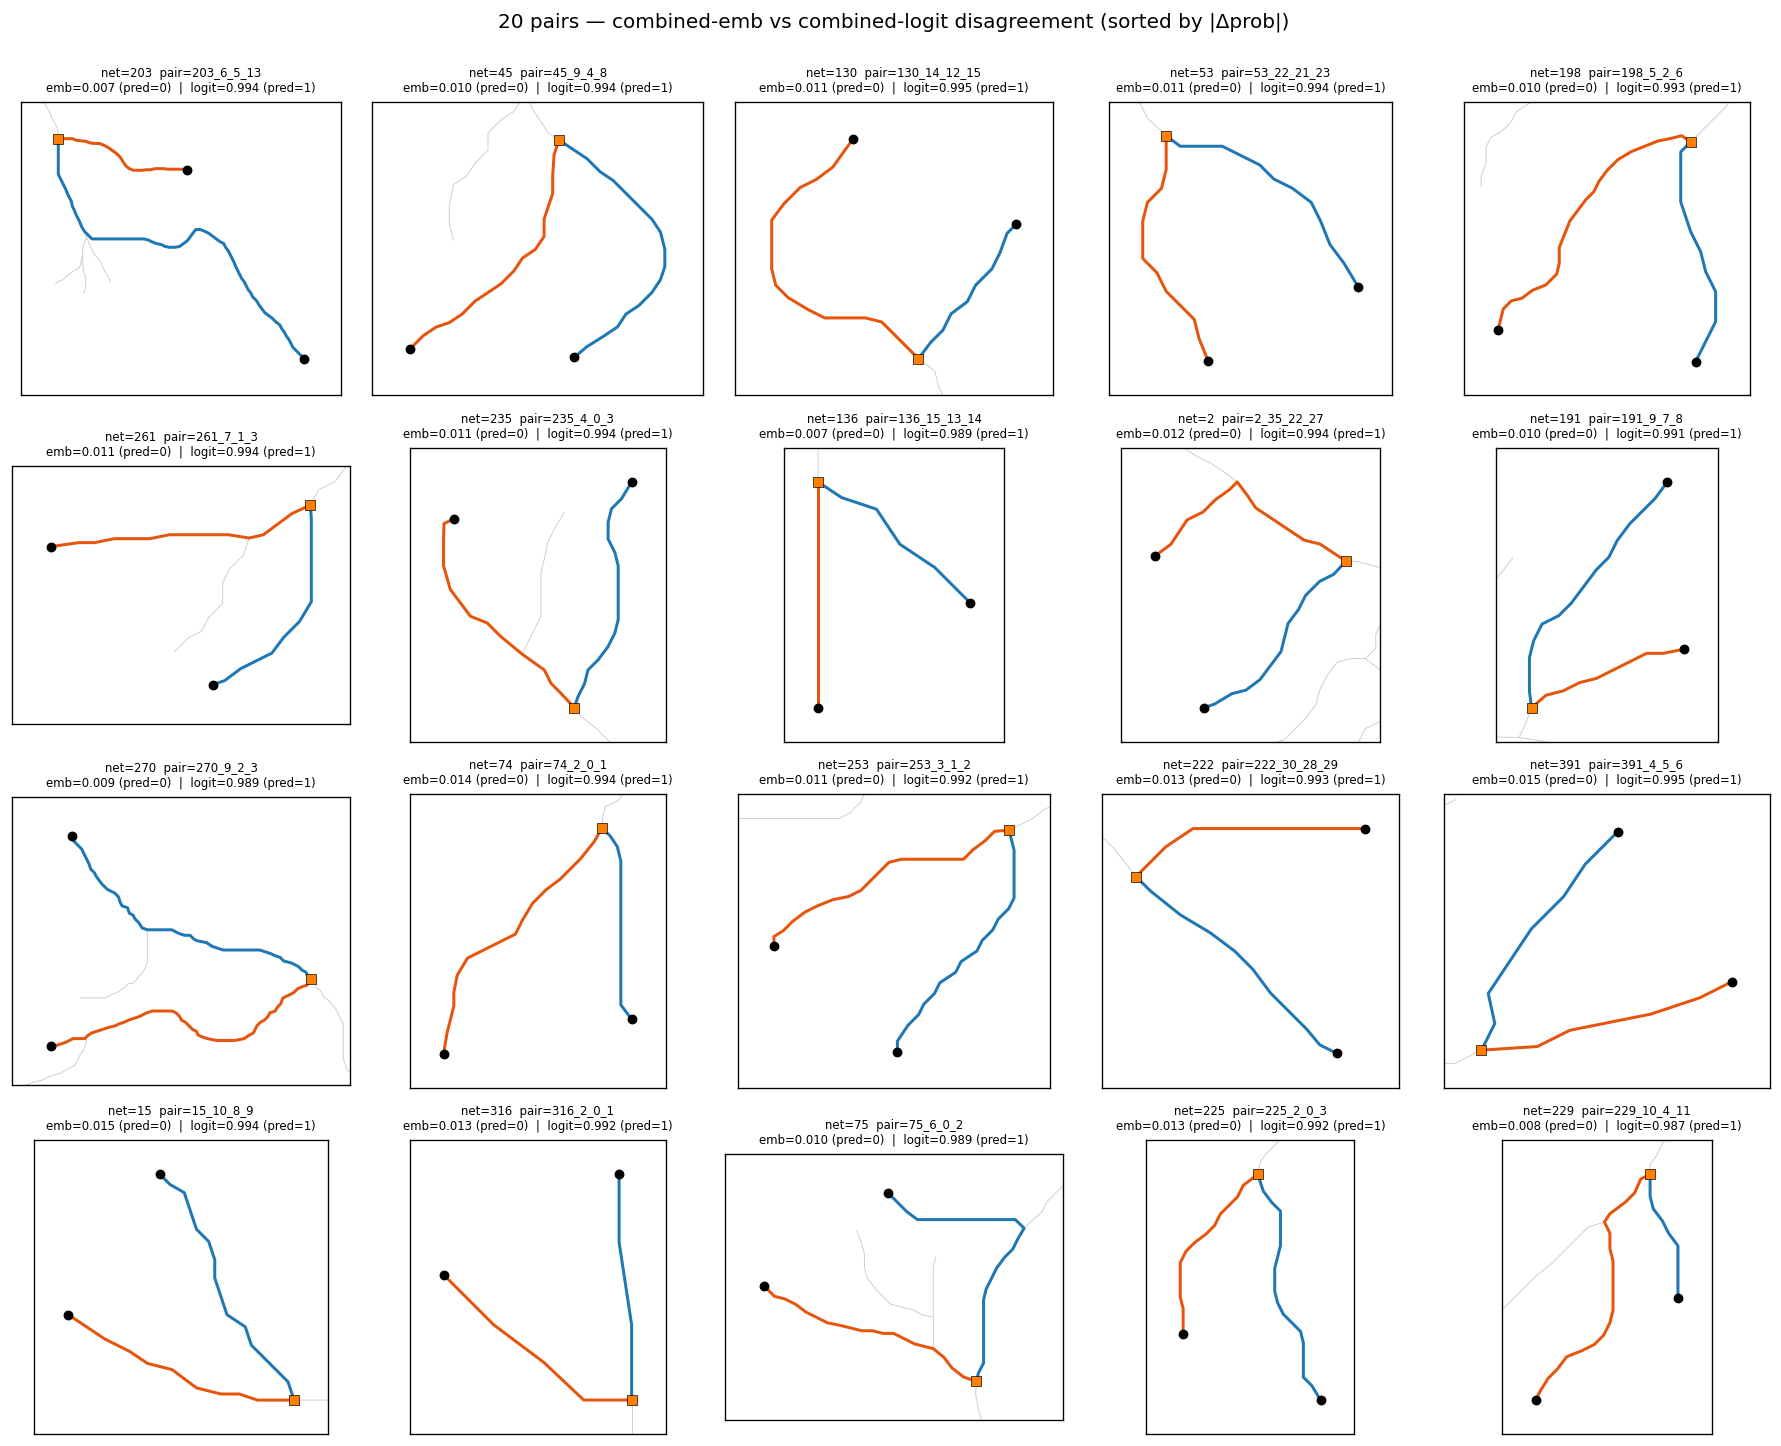

In [3]:
from IPython.display import Image, display
for name in ['mars_networks_channels.png', 'contact_sheet_high_conf_both.png',
             'contact_sheet_disagreement.png']:
    f = figdir / name
    if f.exists():
        print(name); display(Image(filename=str(f)))

Deep dives: `notebooks/presentation/{result_figures,mars_contact_sheets,
per_outlet_touching_pairs}.ipynb`. Per project convention, Mars contact sheets use
**vector polyline** drawings (not raster patches).